# OAR-B (LLM) vs Human-Curated Phrases & Dictionary

This notebook compares two representations of visualization quality comments:

| Source | Data | Format |
|--------|------|--------|
| **OAR-B** | LLM extraction using human-based synset (~300 objects) | JSON: `{objects, attributes, relationships}` per image |
| **Human Phrases** | Manually curated multi-word phrases | CSV: topic × phrase × sentiment |
| **Human Dictionary** | Stemmed vocabulary from curated phrases | CSV: stem × POS × topic weights |

### Analysis Plan
1. Extract & normalize OAR-B vocabulary (split `_`-joined compound terms into tokens)
2. Token-level overlap: OAR tokens ↔ dictionary stems
3. Topic alignment: OAR attribute topics ↔ phrase topics
4. Semantic gap: what each side covers that the other doesn't
5. Phrase reconstructability: can OAR triples express human phrases?

In [1]:
from pathlib import Path
import json, re, collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import chain

ROOT = Path('../..')

# ── paths ────────────────────────────────────────────────────────────────────
OAR_B_66  = ROOT / 'vc_genome_output_full' / 'three_conditions' / 'oar_B.json'
OAR_B_510 = ROOT / 'vc_genome_output_full' / 'three_conditions' / 'oar_B_510.json'
DICT_CSV   = ROOT / 'comment_process' / 'finalDictionary.csv'
PHRASE_CSV = ROOT / 'comment_process' / 'finalCuratedPhrases.csv'

STOPWORDS = {
    'a','an','the','of','in','on','to','at','by','for','with','and','or',
    'is','are','was','were','be','been','being','this','that','it','its',
    'as','from','into','than','more','less','very','too','so','such',
    'each','per','via','due','not','no','non'
}

TOPICS = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load',
]

print('Paths OK:', all(p.exists() for p in [OAR_B_66, OAR_B_510, DICT_CSV, PHRASE_CSV]))

Paths OK: True


## 1. Load Data

In [2]:
# ── OAR-B ─────────────────────────────────────────────────────────────────────
oar_66  = json.loads(OAR_B_66.read_text(encoding='utf-8'))
oar_510 = json.loads(OAR_B_510.read_text(encoding='utf-8'))

# ── Human data ────────────────────────────────────────────────────────────────
df_dict   = pd.read_csv(DICT_CSV)
df_phrase = pd.read_csv(PHRASE_CSV)

print(f'OAR-B  66 images  | {len(oar_66)} entries')
print(f'OAR-B 510 images  | {len(oar_510)} entries')
print(f'Dictionary        | {len(df_dict)} stems')
print(f'Curated phrases   | {len(df_phrase)} phrases')
print()
print('Dict columns  :', df_dict.columns.tolist())
print('Phrase columns:', df_phrase.columns.tolist())
df_dict.head(3)

OAR-B  66 images  | 66 entries
OAR-B 510 images  | 510 entries
Dictionary        | 689 stems
Curated phrases   | 404 phrases

Dict columns  : ['stem', 'source', 'POS', 'totalImages', 'Data Density / Image Clutter', 'Visual Encoding Clarity', 'Semantics / Text Legibility', 'Schema', 'Color, Symbol, and Texture Details', 'Aesthetics Uncertainty', 'Immediacy / Cognitive Load']
Phrase columns: ['topic', 'phrase', 'sentiment', 'num_images', 'Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid', 'Line', 'Node-link', 'Point', 'Text']


,stem,source,POS,totalImages,Data Density / Image Clutter,Visual Encoding Clarity,Semantics / Text Legibility,Schema,"Color, Symbol, and Texture Details",Aesthetics Uncertainty,Immediacy / Cognitive Load
0,color,user comment,"ADJ, NOUN, PROPN, VERB",193.0,96.0,86.0,88.0,56.0,190.0,30.0,84.0
1,understand,user comment,"ADJ, NOUN, VERB",106.0,48.0,41.0,41.0,27.0,46.0,15.0,101.0
2,information,user comment,NOUN,79.0,60.0,33.0,37.0,17.0,40.0,14.0,49.0


## 2. Extract & Normalise OAR Vocabulary

OAR-B uses `snake_case` compound terms.  We tokenise each by splitting on `_`,
lower-case, and remove stopwords to get stem-like tokens for comparison.

In [3]:
def tokenise_term(term: str) -> list[str]:
    """Split snake_case term, lowercase, strip stopwords."""
    return [t for t in term.lower().split('_') if t and t not in STOPWORDS]

def extract_oar_vocab(oar_data: dict) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Return (objects_df, attrs_df, rels_df) with term counts and tokens."""
    obj_rows, attr_rows, rel_rows = [], [], []

    for img, entry in oar_data.items():
        # Objects
        for o in entry.get('objects', []):
            obj_rows.append({'image': img, 'term': o['name'],
                             'tokens': tokenise_term(o['name'])})
        # Attributes
        for a in entry.get('attributes', []):
            attr_rows.append({'image': img, 'term': a['attr'],
                              'tokens': tokenise_term(a['attr']),
                              'sentiment': a.get('sentiment', ''),
                              'topic': a.get('topic', '')})
        # Relationships
        for r in entry.get('relationships', []):
            rel_rows.append({'image': img, 'term': r['pred'],
                             'tokens': tokenise_term(r['pred']),
                             'sentiment': r.get('sentiment', ''),
                             'topic': r.get('topic', '')})

    return (pd.DataFrame(obj_rows),
            pd.DataFrame(attr_rows),
            pd.DataFrame(rel_rows))

df_obj_510, df_attr_510, df_rel_510 = extract_oar_vocab(oar_510)
df_obj_66,  df_attr_66,  df_rel_66  = extract_oar_vocab(oar_66)

# Unique terms per OAR slot (510-image set)
uniq_obj  = df_obj_510.drop_duplicates('term')
uniq_attr = df_attr_510.drop_duplicates('term')
uniq_rel  = df_rel_510.drop_duplicates('term')

print('510-image OAR-B vocabulary:')
print(f'  Objects           : {len(uniq_obj)} unique terms')
print(f'  Attributes        : {len(uniq_attr)} unique terms')
print(f'  Relationship preds: {len(uniq_rel)} unique terms')

# All flat tokens from OAR
all_oar_tokens = set(chain.from_iterable(
    chain(df_obj_510['tokens'], df_attr_510['tokens'], df_rel_510['tokens'])
))
print(f'\nDistinct tokens in OAR-B (510): {len(all_oar_tokens)}')

510-image OAR-B vocabulary:
  Objects           : 368 unique terms
  Attributes        : 1510 unique terms
  Relationship preds: 451 unique terms

Distinct tokens in OAR-B (510): 1186


In [4]:
# Token frequency across all OAR roles
token_counter = collections.Counter(
    chain.from_iterable(
        chain(df_obj_510['tokens'], df_attr_510['tokens'], df_rel_510['tokens'])
    )
)

df_oar_tokens = pd.DataFrame(
    [(tok, cnt) for tok, cnt in token_counter.most_common()],
    columns=['token', 'oar_freq']
)

# Which OAR role each token comes from (can be multiple)
obj_toks  = set(chain.from_iterable(df_obj_510['tokens']))
attr_toks = set(chain.from_iterable(df_attr_510['tokens']))
rel_toks  = set(chain.from_iterable(df_rel_510['tokens']))

def oar_roles(tok):
    roles = []
    if tok in obj_toks:  roles.append('O')
    if tok in attr_toks: roles.append('A')
    if tok in rel_toks:  roles.append('R')
    return '+'.join(roles)

df_oar_tokens['oar_roles'] = df_oar_tokens['token'].map(oar_roles)
print(df_oar_tokens.head(20).to_string(index=False))

        token  oar_freq oar_roles
        color       288       O+A
    increases       218       A+R
        chart       208       O+A
         data       208     O+A+R
      present       198         A
       colors       181     O+A+R
         high       173       A+R
         text       155     O+A+R
       labels       147     O+A+R
     multiple       141       A+R
visualization       139       O+A
    cognitive       128       A+R
      clutter       128       A+R
         load       122       A+R
     elements       114     O+A+R
       visual       108     O+A+R
  contributes       107       A+R
     encoding        98     O+A+R
        lines        96       O+A
  information        93     O+A+R


## 3. Token-Level Overlap: OAR ↔ Dictionary

In [5]:
dict_stems = set(df_dict['stem'].str.lower().str.strip())

# Overlap
in_both      = all_oar_tokens & dict_stems
only_in_oar  = all_oar_tokens - dict_stems
only_in_dict = dict_stems - all_oar_tokens

print(f'Dictionary stems         : {len(dict_stems)}')
print(f'OAR tokens (510 images)  : {len(all_oar_tokens)}')
print(f'Shared (exact match)     : {len(in_both)}  ({100*len(in_both)/len(dict_stems):.1f}% of dict)')
print(f'Only in OAR              : {len(only_in_oar)}')
print(f'Only in dict (not in OAR): {len(only_in_dict)}')

# Annotate the token table
df_oar_tokens['in_dict'] = df_oar_tokens['token'].isin(dict_stems)

# Annotate dictionary with coverage
df_dict['in_oar'] = df_dict['stem'].str.lower().str.strip().isin(all_oar_tokens)

Dictionary stems         : 688
OAR tokens (510 images)  : 1186
Shared (exact match)     : 453  (65.8% of dict)
Only in OAR              : 733
Only in dict (not in OAR): 235


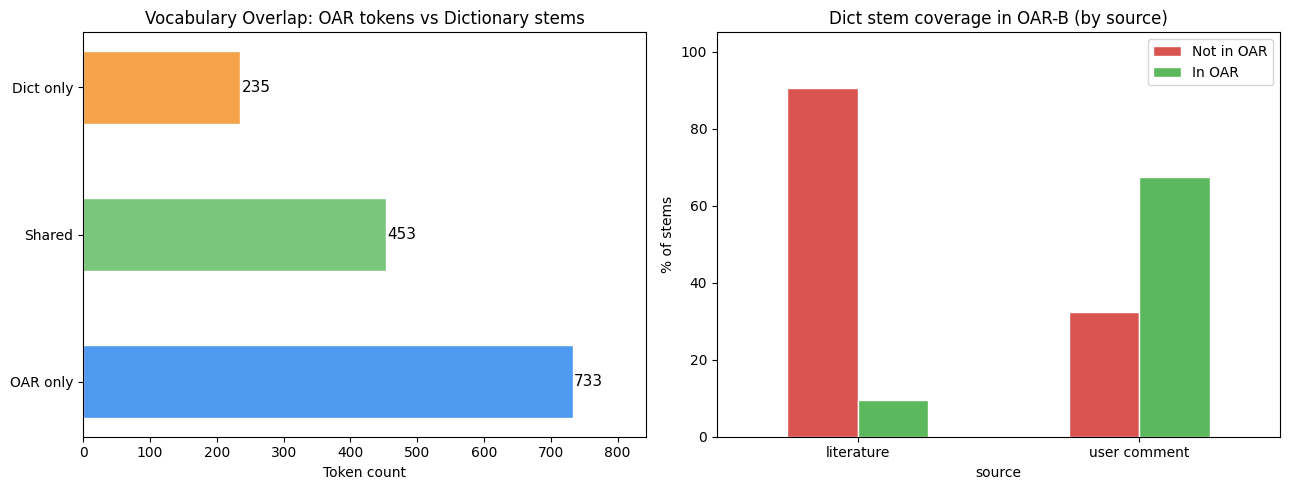

Saved figures/oar_vs_dict_overlap.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Venn-style bar ───────────────────────────────────────────────────────────
ax = axes[0]
sets   = ['OAR only', 'Shared', 'Dict only']
counts = [len(only_in_oar), len(in_both), len(only_in_dict)]
colors = ['#4e9af1', '#7ac67a', '#f4a34a']
bars = ax.barh(sets, counts, color=colors, edgecolor='white', height=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=11)
ax.set_xlabel('Token count')
ax.set_title('Vocabulary Overlap: OAR tokens vs Dictionary stems')
ax.set_xlim(0, max(counts) * 1.15)

# ── Dict coverage by source ───────────────────────────────────────────────────
ax2 = axes[1]
cov = df_dict.groupby('source')['in_oar'].value_counts(normalize=True).unstack(fill_value=0) * 100
cov.plot(kind='bar', ax=ax2, color=['#d9534f','#5cb85c'], edgecolor='white', width=0.5)
ax2.set_ylabel('% of stems')
ax2.set_title('Dict stem coverage in OAR-B (by source)')
ax2.set_xticklabels(cov.index, rotation=0)
ax2.legend(['Not in OAR', 'In OAR'], loc='upper right')
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'oar_vs_dict_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/oar_vs_dict_overlap.png')

In [7]:
# Dictionary stems NOT covered by OAR (grouped by POS)
df_uncovered = df_dict[~df_dict['in_oar']].copy()

# Flatten multi-POS entries for grouping
pos_counts = collections.Counter()
for pos_str in df_uncovered['POS'].dropna():
    for p in str(pos_str).split(','):
        pos_counts[p.strip()] += 1

print(f'== Dict stems NOT in OAR ({len(df_uncovered)}) ==')
print(f'POS breakdown: {dict(pos_counts.most_common())}')
print()

# Top-frequency uncovered stems
top_uncov = df_uncovered.nlargest(30, 'totalImages')[['stem','POS','source','totalImages']]
print('Top-frequency dict stems absent from OAR:')
print(top_uncov.to_string(index=False))

== Dict stems NOT in OAR (236) ==
POS breakdown: {'VERB': 96, 'NOUN': 95, 'ADJ': 24, 'ADV': 9, 'PROPN': 6, 'PART': 1, 'PRON': 1, 'ADP': 1}

Top-frequency dict stems absent from OAR:
      stem             POS       source  totalImages
     datum            NOUN user comment         48.0
   confuse       ADJ, VERB user comment         19.0
      know            VERB user comment         18.0
      mean      NOUN, VERB user comment         17.0
     write      NOUN, VERB user comment         13.0
      need      NOUN, VERB user comment         12.0
        go            VERB user comment         12.0
      show            VERB user comment         11.0
      idea            NOUN user comment          8.0
       mix      NOUN, VERB user comment          8.0
     thing            NOUN user comment          7.0
      sure             ADJ user comment          6.0
distribute      NOUN, VERB user comment          5.0
   require            VERB user comment          5.0
    relate ADV, NOUN, V

In [8]:
# OAR tokens NOT in dict (top frequency)
df_oar_novel = df_oar_tokens[~df_oar_tokens['in_dict']].copy()
print(f'== OAR tokens NOT in dictionary ({len(df_oar_novel)}) ==')
print()
print('Most frequent OAR-only tokens:')
print(df_oar_novel.nlargest(30, 'oar_freq')[['token','oar_freq','oar_roles']].to_string(index=False))

== OAR tokens NOT in dictionary (733) ==

Most frequent OAR-only tokens:
         token  oar_freq oar_roles
     increases       218       A+R
        colors       181     O+A+R
        labels       147     O+A+R
 visualization       139       O+A
          load       122       A+R
      elements       114     O+A+R
   contributes       107       A+R
      encoding        98     O+A+R
         lines        96       O+A
        shapes        80       O+A
    complexity        78       A+R
      requires        77       A+R
        points        73       O+A
          many        72       A+R
interpretation        64       A+R
          adds        61       A+R
       reduces        56       A+R
          used        53         A
     different        40         A
         count        39         A
       meaning        38       A+R
       numbers        37     O+A+R
         lacks        35       A+R
      visually        35       A+R
          aids        33       A+R
         words   

## 4. Topic Alignment

In [9]:
# ── OAR-B topic distribution (attrs + rels, 510 images) ─────────────────────
oar_topic_counts = pd.concat([
    df_attr_510['topic'].value_counts().rename('attributes'),
    df_rel_510['topic'].value_counts().rename('relationships'),
], axis=1).fillna(0).astype(int)
oar_topic_counts['total'] = oar_topic_counts.sum(axis=1)
oar_topic_counts = oar_topic_counts.sort_values('total', ascending=False)

# ── Human phrase topic distribution ──────────────────────────────────────────
phrase_topic = df_phrase.groupby('topic')['num_images'].sum().rename('phrase_images')

# ── Dict topic weights (sum per topic column) ────────────────────────────────
dict_topic = df_dict[TOPICS].sum().rename('dict_image_count')

# ── Combined view ─────────────────────────────────────────────────────────────
df_topic_align = pd.DataFrame({
    'oar_total':      oar_topic_counts['total'],
    'phrase_images':  phrase_topic,
    'dict_coverage':  dict_topic,
}).fillna(0).astype(int)
df_topic_align = df_topic_align.reindex(TOPICS)

print('Topic-level alignment:')
print(df_topic_align.to_string())

Topic-level alignment:
                                    oar_total  phrase_images  dict_coverage
Data Density / Image Clutter              480            363           1949
Visual Encoding Clarity                   425            314           1773
Semantics / Text Legibility               378            318           1818
Schema                                    163            159           1254
Color, Symbol, and Texture Details        399            323           2105
Aesthetics Uncertainty                    313             62            719
Immediacy / Cognitive Load                640            388           2170


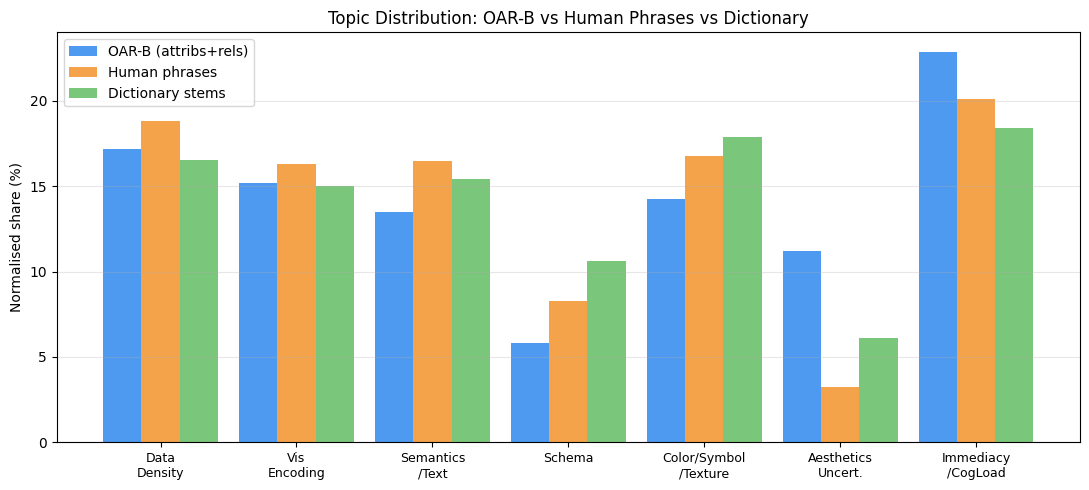

Saved figures/oar_vs_human_topic_align.png


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(TOPICS))
w = 0.28

# Normalise to 0-100 for comparability
def norm(col): return 100 * col / col.sum() if col.sum() > 0 else col

r1 = ax.bar(x - w, norm(df_topic_align['oar_total']),      w, label='OAR-B (attribs+rels)', color='#4e9af1')
r2 = ax.bar(x,     norm(df_topic_align['phrase_images']),  w, label='Human phrases',         color='#f4a34a')
r3 = ax.bar(x + w, norm(df_topic_align['dict_coverage']),  w, label='Dictionary stems',      color='#7ac67a')

short_labels = [
    'Data\nDensity', 'Vis\nEncoding', 'Semantics\n/Text', 'Schema',
    'Color/Symbol\n/Texture', 'Aesthetics\nUncert.', 'Immediacy\n/CogLoad'
]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel('Normalised share (%)')
ax.set_title('Topic Distribution: OAR-B vs Human Phrases vs Dictionary')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'oar_vs_human_topic_align.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/oar_vs_human_topic_align.png')

## 5. Phrase-Level Analysis

Tokenise each human phrase and check what fraction of its words appear in OAR vocabulary.
A high overlap suggests OAR *could* reconstruct that concept; a low overlap means a semantic gap.

In [11]:
def tokenise_phrase(ph: str) -> list[str]:
    """Tokenise a human phrase: lowercase, split on whitespace/punctuation, strip stopwords."""
    raw = re.split(r'[\s/,;\-]+', ph.lower())
    return [t for t in raw if t and t not in STOPWORDS]

df_phrase = df_phrase.copy()
df_phrase['tokens'] = df_phrase['phrase'].map(tokenise_phrase)
df_phrase['n_tokens'] = df_phrase['tokens'].map(len)

# For each phrase: how many tokens exist in OAR vocabulary?
df_phrase['oar_overlap_n']  = df_phrase['tokens'].map(
    lambda toks: sum(1 for t in toks if t in all_oar_tokens)
)
df_phrase['oar_overlap_pct'] = np.where(
    df_phrase['n_tokens'] > 0,
    df_phrase['oar_overlap_n'] / df_phrase['n_tokens'],
    0.0
)

# How many phrase tokens are in the dictionary?
df_phrase['dict_overlap_n']  = df_phrase['tokens'].map(
    lambda toks: sum(1 for t in toks if t in dict_stems)
)
df_phrase['dict_overlap_pct'] = np.where(
    df_phrase['n_tokens'] > 0,
    df_phrase['dict_overlap_n'] / df_phrase['n_tokens'],
    0.0
)

print('Phrase coverage summary:')
print(f'  Mean OAR token overlap  : {df_phrase["oar_overlap_pct"].mean():.2%}')
print(f'  Mean dict token overlap : {df_phrase["dict_overlap_pct"].mean():.2%}')
print()
print(f'  Phrases fully covered by OAR (100%): {(df_phrase["oar_overlap_pct"] == 1).sum()}')
print(f'  Phrases with zero OAR coverage     : {(df_phrase["oar_overlap_pct"] == 0).sum()}')

Phrase coverage summary:
  Mean OAR token overlap  : 93.62%
  Mean dict token overlap : 57.29%

  Phrases fully covered by OAR (100%): 346
  Phrases with zero OAR coverage     : 6


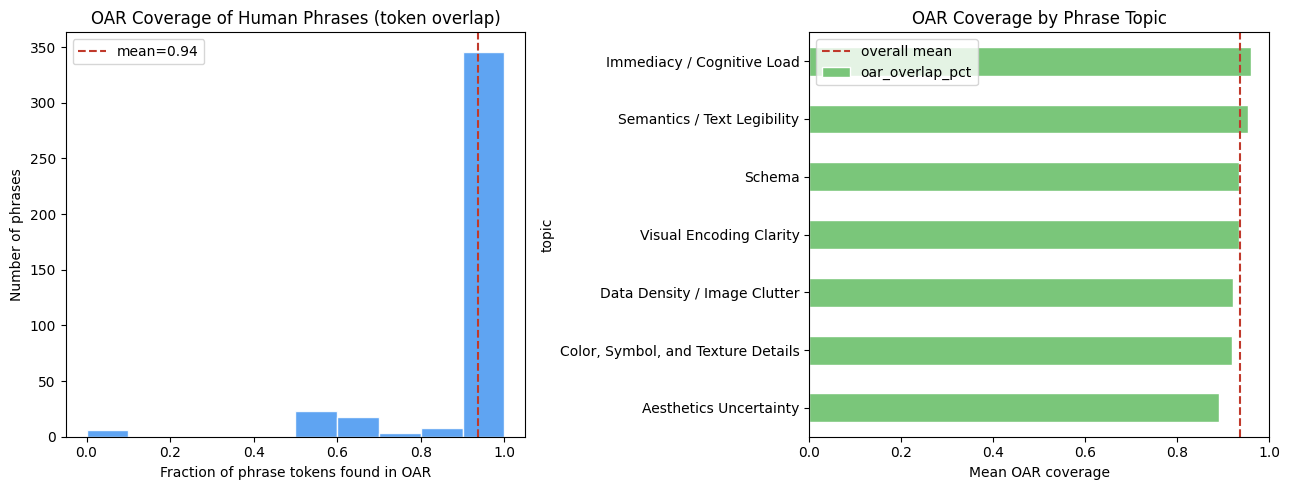

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── OAR overlap distribution ──────────────────────────────────────────────────
ax = axes[0]
bins = np.linspace(0, 1, 11)
ax.hist(df_phrase['oar_overlap_pct'], bins=bins, color='#4e9af1', edgecolor='white', alpha=0.9)
ax.axvline(df_phrase['oar_overlap_pct'].mean(), color='#c0392b', lw=1.5, ls='--',
           label=f'mean={df_phrase["oar_overlap_pct"].mean():.2f}')
ax.set_xlabel('Fraction of phrase tokens found in OAR')
ax.set_ylabel('Number of phrases')
ax.set_title('OAR Coverage of Human Phrases (token overlap)')
ax.legend()

# ── By topic ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
topic_cov = df_phrase.groupby('topic')['oar_overlap_pct'].mean().sort_values()
topic_cov.plot(kind='barh', ax=ax2, color='#7ac67a', edgecolor='white')
ax2.axvline(df_phrase['oar_overlap_pct'].mean(), color='#c0392b', lw=1.5, ls='--', label='overall mean')
ax2.set_xlabel('Mean OAR coverage')
ax2.set_title('OAR Coverage by Phrase Topic')
ax2.legend()
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'oar_phrase_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Phrases with lowest OAR coverage — these represent semantic gaps
print('=== Phrases with ZERO OAR token overlap (semantic gaps) ===')
zero_cov = df_phrase[df_phrase['oar_overlap_pct'] == 0][['topic','phrase','sentiment','num_images']]
print(zero_cov.sort_values('num_images', ascending=False).to_string(index=False))

=== Phrases with ZERO OAR token overlap (semantic gaps) ===
                             topic         phrase sentiment  num_images
           Visual Encoding Clarity   nonlinearity       (+)           2
Color, Symbol, and Texture Details    more pixels       (+)           1
      Data Density / Image Clutter    disposition       (+)           1
       Semantics / Text Legibility          dates       (+)           1
           Visual Encoding Clarity     misaligned       (+)           1
           Visual Encoding Clarity no interaction       (-)           1


In [14]:
# Phrases with FULL OAR coverage — these OAR can reconstruct
print('=== Phrases fully covered by OAR vocabulary ===')
full_cov = df_phrase[df_phrase['oar_overlap_pct'] == 1.0][['topic','phrase','sentiment','num_images']]
print(full_cov.sort_values('num_images', ascending=False).head(30).to_string(index=False))

=== Phrases fully covered by OAR vocabulary ===
                             topic                                                    phrase sentiment  num_images
Color, Symbol, and Texture Details                    color variety/arrangement/distribution   (+) (-)          87
      Data Density / Image Clutter                  more charts/points/lines/shapes/elements   (+) (-)          79
      Data Density / Image Clutter                           much/more data/info/info spread   (+) (-)          65
        Immediacy / Cognitive Load                         easy to interpret/read/understand   (+) (-)          55
       Semantics / Text Legibility                             title/axis/label/descriptions   (+) (-)          37
        Immediacy / Cognitive Load                         hard to interpret/read/understand       (+)          33
                            Schema                              unfamiliar concepts/patterns       (+)          32
        Immediacy / Cognitive Lo

## 6. Reverse Coverage: Can OAR Attribute/Rel Terms Be Explained by Human Phrases?

In [15]:
# Build phrase-token index: token -> list of phrases that contain it
phrase_token_index = collections.defaultdict(list)
for _, row in df_phrase.iterrows():
    for tok in row['tokens']:
        phrase_token_index[tok].append(row['phrase'])

def oar_term_to_phrases(term: str) -> list[str]:
    """Return human phrases that share tokens with an OAR term."""
    tokens = tokenise_term(term)
    matched = set()
    for t in tokens:
        matched.update(phrase_token_index.get(t, []))
    return sorted(matched)

# For each unique attribute term, find matching human phrases
attr_phrase_rows = []
for _, row in uniq_attr.iterrows():
    matches = oar_term_to_phrases(row['term'])
    attr_phrase_rows.append({
        'oar_term'     : row['term'],
        'n_phrase_match': len(matches),
        'matched_phrases': ' | '.join(matches[:5]) if matches else '—',
    })

df_attr_phrase = pd.DataFrame(attr_phrase_rows).sort_values('n_phrase_match', ascending=False)

covered_attr  = (df_attr_phrase['n_phrase_match'] > 0).sum()
print(f'Unique OAR attributes : {len(df_attr_phrase)}')
print(f'Matched to >= 1 phrase: {covered_attr} ({100*covered_attr/len(df_attr_phrase):.1f}%)')
print()
print('Top-matched OAR attribute terms:')
print(df_attr_phrase.head(20)[['oar_term','n_phrase_match','matched_phrases']].to_string(index=False))

Unique OAR attributes : 1510
Matched to >= 1 phrase: 1389 (92.0%)

Top-matched OAR attribute terms:
                     oar_term  n_phrase_match                                                                                                                    matched_phrases
  unclear_color_value_meaning              55                                         axis meaning | black color | black-to-white/color gradient | blue color | clear color uses
 unclear_color_representation              54                                        black color | black-to-white/color gradient | blue color | clear color uses | color details
        unclear_color_meaning              52                                         axis meaning | black color | black-to-white/color gradient | blue color | clear color uses
        color_meaning_unclear              52                                         axis meaning | black color | black-to-white/color gradient | blue color | clear color uses
           many

In [16]:
# OAR attribute terms with NO phrase match — pure LLM invention
print('=== OAR attribute terms with NO human phrase match ===')
no_match = df_attr_phrase[df_attr_phrase['n_phrase_match'] == 0]['oar_term'].values
print(f'{len(no_match)} terms')
for t in no_match[:40]:
    print(f'  {t}')

=== OAR attribute terms with NO human phrase match ===
121 terms
  paths_diverge_and_overlap
  less_writing_present
  vast_interpretations_possible
  overly_colorful
  titles_present
  high_dot_count
  high_interpretive_difficulty
  too_dark
  variations_of_shade
  requires_concentration
  traditional_statistics_reporting
  cohesive_whole
  purpose_clearly_communicated
  circular_chart_form
  non_linear_pattern
  never_seen_before
  no_metrics_present
  continent_with_countries
  geo_map_format
  africa_map_recognized
  animal_shaped_marks
  increased_cognitive_load
  more_distinct_areas
  appears_less_important
  high_entity_count
  temporal_comparison_required
  high_object_count
  extends_horizontally
  high_cognitive_load
  has_internal_logic
  circular_mark_present
  unrecognized_countries
  summarizes_at_glance
  varying_amounts
  high_letter_count
  high_item_count
  high_volume_of_writing
  arranged_side_by_side
  numerous_names_present
  requires_extended_decoding


## 7. Relationship Predicates vs Human Phrases

In [17]:
rel_phrase_rows = []
for _, row in uniq_rel.iterrows():
    matches = oar_term_to_phrases(row['term'])
    rel_phrase_rows.append({
        'oar_pred'       : row['term'],
        'n_phrase_match' : len(matches),
        'matched_phrases': ' | '.join(matches[:4]) if matches else '—',
    })

df_rel_phrase = pd.DataFrame(rel_phrase_rows).sort_values('n_phrase_match', ascending=False)

covered_rel = (df_rel_phrase['n_phrase_match'] > 0).sum()
print(f'Unique OAR relationship predicates : {len(df_rel_phrase)}')
print(f'Matched to >= 1 human phrase       : {covered_rel} ({100*covered_rel/len(df_rel_phrase):.1f}%)')
print()
print(df_rel_phrase.head(20).to_string(index=False))

Unique OAR relationship predicates : 451
Matched to >= 1 human phrase       : 210 (46.6%)

                                 oar_pred  n_phrase_match                                                                                                                              matched_phrases
                   reflects_few_colors_in              27                                      abstract shapes or colors | ambiguous/confusing colors | amount of / too many colors | appealing colors
                   contains_many_elements              26                amount of / too many colors | dense points/lines/shapes/elements | few points/lines/shapes/elements | intense/too many colors
             adds_information_elements_to              25                                clear text/scale/information | dense points/lines/shapes/elements | diverse information | factual information
                        encodes_colors_of              24                                      abstract shapes or

## 8. OAR Triple → Natural Language (Reconstructed Descriptions)

Render each OAR triple `(subject_object) predicate (object_object)` as a sentence
and compare against human phrases to see which triples have close phrase analogues.

In [18]:
def term_to_nl(term: str) -> str:
    """Convert snake_case OAR term to human-readable words."""
    return term.replace('_', ' ')

triple_rows = []
for img, entry in oar_66.items():          # use 66-image eval set for manageable output
    obj_map = {o['id']: o['name'] for o in entry.get('objects', [])}
    for r in entry.get('relationships', []):
        subj_name = obj_map.get(r['subj'], f'obj{r["subj"]}')
        obj_name  = obj_map.get(r['obj'],  f'obj{r["obj"]}')
        sentence  = f"{term_to_nl(subj_name)} {term_to_nl(r['pred'])} {term_to_nl(obj_name)}"
        triple_rows.append({
            'image'     : img,
            'subject'   : subj_name,
            'predicate' : r['pred'],
            'object'    : obj_name,
            'sentence'  : sentence,
            'topic'     : r.get('topic', ''),
            'sentiment' : r.get('sentiment', ''),
        })

df_triples = pd.DataFrame(triple_rows)
print(f'{len(df_triples)} relationship triples across 66 images')
print()
print('Sample reconstructed sentences:')
print(df_triples.sample(min(10, len(df_triples)), random_state=42)[['sentence','topic','sentiment']].to_string(index=False))

165 relationship triples across 66 images

Sample reconstructed sentences:
                                            sentence                        topic sentiment
                     dots increases clutter in chart Data Density / Image Clutter         +
          color scheme enhances readability of chart       Aesthetics Uncertainty         -
       text labels increases cognitive load of chart   Immediacy / Cognitive Load         +
chart type requires domain knowledge for data points   Immediacy / Cognitive Load         +
                       squares scattered across axes       Aesthetics Uncertainty         +
            lines contributes to clutter with shapes Data Density / Image Clutter         +
  axis labels contains confusing names in line chart  Semantics / Text Legibility         +
                bar graph combined with circle graph Data Density / Image Clutter         +
               data details adds complexity to graph Data Density / Image Clutter         +
     

## 9. Summary Dashboard

In [19]:
summary = {
    'Metric': [
        'OAR-B images (full set)',
        'OAR unique object terms',
        'OAR unique attribute terms',
        'OAR unique rel. predicates',
        'OAR distinct tokens (after split)',
        '—',
        'Human curated phrases',
        'Human dictionary stems',
        'Dict stems: user-comment derived',
        'Dict stems: literature-derived',
        '—',
        'Dict stems found in OAR tokens',
        'Dict stems NOT in OAR',
        'OAR tokens NOT in dictionary',
        '—',
        'OAR attr. terms matched to ≥1 phrase',
        'OAR attr. terms with no phrase match',
        'Mean phrase token OAR coverage',
        'Phrases fully covered by OAR',
        'Phrases with zero OAR coverage',
    ],
    'Value': [
        len(oar_510),
        len(uniq_obj),
        len(uniq_attr),
        len(uniq_rel),
        len(all_oar_tokens),
        '',
        len(df_phrase),
        len(df_dict),
        (df_dict['source'] == 'user comment').sum(),
        (df_dict['source'] == 'literature').sum(),
        '',
        len(in_both),
        len(only_in_dict),
        len(only_in_oar),
        '',
        covered_attr,
        len(df_attr_phrase) - covered_attr,
        f"{df_phrase['oar_overlap_pct'].mean():.1%}",
        (df_phrase['oar_overlap_pct'] == 1.0).sum(),
        (df_phrase['oar_overlap_pct'] == 0.0).sum(),
    ]
}
df_summary = pd.DataFrame(summary)
df_summary.index = [''] * len(df_summary)
print(df_summary.to_string(index=False))

                              Metric Value
             OAR-B images (full set)   510
             OAR unique object terms   368
          OAR unique attribute terms  1510
          OAR unique rel. predicates   451
   OAR distinct tokens (after split)  1186
                                   —      
               Human curated phrases   404
              Human dictionary stems   689
    Dict stems: user-comment derived   668
      Dict stems: literature-derived    21
                                   —      
      Dict stems found in OAR tokens   453
               Dict stems NOT in OAR   235
        OAR tokens NOT in dictionary   733
                                   —      
OAR attr. terms matched to ≥1 phrase  1389
OAR attr. terms with no phrase match   121
      Mean phrase token OAR coverage 93.6%
        Phrases fully covered by OAR   346
      Phrases with zero OAR coverage     6


In [20]:
# Save gap tables for further review
out_dir = ROOT / 'figures'

zero_cov.to_csv(out_dir / 'oar_vs_human_phrase_gaps.csv', index=False)
df_uncovered[['stem','POS','source','totalImages']].to_csv(
    out_dir / 'dict_stems_absent_from_oar.csv', index=False)
df_attr_phrase.to_csv(out_dir / 'oar_attr_phrase_match.csv', index=False)

print('Saved:')
print('  figures/oar_vs_human_phrase_gaps.csv')
print('  figures/dict_stems_absent_from_oar.csv')
print('  figures/oar_attr_phrase_match.csv')

Saved:
  figures/oar_vs_human_phrase_gaps.csv
  figures/dict_stems_absent_from_oar.csv
  figures/oar_attr_phrase_match.csv
